# 六家券商金股行业分析报告

**分析目标**：基于券商金股推荐数据，按头部（中信建投+华泰）、腰部（招商+平安）、尾部（天风+开源）三个梯队，分析六家券商的行业偏好、推荐集中度及收益率表现。

**数据来源**：broker_gold_stocks.xlsx + akShare 申万行业指数

## 1. 数据读取与清洗

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import akshare as ak
import warnings
warnings.filterwarnings('ignore')

# ======================
# MacOS中文显示终极解决方案
# ======================
# 尝试所有MacOS系统自带的中文字体，按优先级排序
chinese_fonts = [
    "PingFang SC",        # 苹方（MacOS 10.11+ 默认）
    "Heiti TC",           # 黑体-繁
    "Heiti SC",           # 黑体-简
    "Arial Unicode MS",   # 万能Unicode字体
    "Songti SC",          # 宋体-简
    "STHeiti",            # 华文黑体
    "STSong"              # 华文宋体
]

# 自动选择第一个可用的中文字体
for font in chinese_fonts:
    if font in [f.name for f in fm.fontManager.ttflist]:
        plt.rcParams["font.family"] = font
        print(f"✅ 成功加载中文字体：{font}")
        break
else:
    print("⚠️ 未找到系统中文字体，将使用英文显示")

✅ 成功加载中文字体：Heiti TC


In [18]:
# ---------- 读取数据 ----------
df = pd.read_excel('broker_gold_stocks.xlsx', sheet_name='合并数据')
df_summary = pd.read_excel('broker_gold_stocks.xlsx', sheet_name='汇总统计', header=None)

print(f"合并数据: {df.shape[0]} 行, {df.shape[1]} 列")
print(f"列名: {df.columns.tolist()}")
print(f"\n推荐月份范围: {df['推荐月份'].min()} ~ {df['推荐月份'].max()}")
print(f"券商: {sorted(df['机构名称'].unique())}")
print(f"Wind一级行业数: {df['Wind一级行业'].nunique()}")
print(f"\n各券商数据量:")
print(df['机构名称'].value_counts())

合并数据: 889 行, 17 列
列名: ['序号', '机构名称', '推荐月份', '文件来源', '证券代码', '证券简称', '上一月涨跌幅(%)', '当月涨跌幅(%)', 'Wind一级行业', '近3个月推荐次数(单家)', '近3个月推荐次数(全部)', '最新目标价', '最新评级', '最新研究日期', '首次覆盖时间', '推荐逻辑', '报告链接']

推荐月份范围: 2025-04-30 ~ 2026-04-30
券商: ['中信建投证券', '华泰证券', '天风证券', '平安证券', '开源证券', '招商证券']
Wind一级行业数: 11

各券商数据量:
机构名称
天风证券      362
平安证券      129
开源证券      112
中信建投证券    107
招商证券      104
华泰证券       75
Name: count, dtype: int64


In [19]:
# ---------- 数据清洗 ----------
df_clean = df[['机构名称', '推荐月份', '证券代码', '证券简称', 'Wind一级行业',
                '当月涨跌幅(%)', '上一月涨跌幅(%)', '最新评级']].copy()
df_clean.columns = ['券商', '月份', '股票代码', '股票名称', '行业',
                    '当月涨跌幅', '上一月涨跌幅', '最新评级']

df_clean = df_clean.dropna(subset=['行业', '股票代码'])
print(f"清洗后数据: {len(df_clean)} 行")

# ---------- 券商梯队映射（来自汇总统计sheet）----------
tier_rows = df_summary.iloc[2:8]
tier_map = {}
for _, row in tier_rows.iterrows():
    tier_map[row.iloc[0]] = row.iloc[1]

print("\n梯队映射:")
for k, v in tier_map.items():
    print(f"  {k}: {v}")

df_clean['梯队'] = df_clean['券商'].map(tier_map)
assert df_clean['梯队'].isna().sum() == 0, "有券商的梯队未匹配!"

df_clean['月份_dt'] = pd.to_datetime(df_clean['月份'])
print(f"\n清洗后数据预览:")
print(df_clean[['券商', '梯队', '行业', '月份', '当月涨跌幅']].head(8))

清洗后数据: 889 行

梯队映射:
  中信建投证券: 头部
  华泰证券: 头部
  天风证券: 尾部
  平安证券: 腰部
  开源证券: 尾部
  招商证券: 腰部

清洗后数据预览:
     券商  梯队    行业          月份    当月涨跌幅
0  华泰证券  头部    材料  2025-04-30  -5.0000
1  华泰证券  头部    材料  2025-04-30  -0.8646
2  华泰证券  头部    工业  2025-04-30  -0.7022
3  华泰证券  头部    工业  2025-04-30  -0.9439
4  华泰证券  头部  可选消费  2025-04-30   0.2200
5  开源证券  尾部  医疗保健  2025-04-30 -10.2238
6  开源证券  尾部  日常消费  2025-04-30   2.4271
7  开源证券  尾部  公用事业  2025-04-30   0.2172


In [20]:
# ---------- 验证汇总统计数据准确性 ----------
actual_counts = df_clean.groupby('券商').size().sort_values(ascending=False)

summary_counts = {}
for _, row in df_summary.iloc[2:8].iterrows():
    summary_counts[row.iloc[0]] = int(row.iloc[2])

print("=" * 50)
print("  验证：合并数据 vs 汇总统计 sheet")
print("=" * 50)
print(f"{'券商':12s} {'合并数据':>8s} {'汇总统计':>8s} {'差异':>6s}")
print("-" * 38)

all_match = True
for broker in actual_counts.index:
    actual = actual_counts[broker]
    stated = summary_counts.get(broker, 0)
    diff = actual - stated
    status = ""
    if diff != 0:
        all_match = False
        status = " <-- 不一致!"
    print(f"{broker:12s} {actual:>8d} {stated:>8d} {diff:>+6d}{status}")

# 按梯队汇总
print(f"\n--- 按梯队汇总 ---")
for tier in ['头部', '腰部', '尾部']:
    brokers_in_tier = [b for b, t in tier_map.items() if t == tier]
    actual_sum = df_clean[df_clean['梯队'] == tier].shape[0]
    stated_sum = sum(summary_counts.get(b, 0) for b in brokers_in_tier)
    print(f"  {tier} ({', '.join(brokers_in_tier)}):")
    print(f"    合并数据={actual_sum}, 汇总统计={stated_sum}, 差异={actual_sum - stated_sum}")

if all_match:
    print("\n验证通过：合并数据与汇总统计 sheet 数据一致")
else:
    print("\n存在差异，以合并数据为准继续分析")

  验证：合并数据 vs 汇总统计 sheet
券商               合并数据     汇总统计     差异
--------------------------------------
天风证券              362      362     +0
平安证券              129      129     +0
开源证券              112      112     +0
中信建投证券            107      107     +0
招商证券              104      104     +0
华泰证券               75       75     +0

--- 按梯队汇总 ---
  头部 (中信建投证券, 华泰证券):
    合并数据=182, 汇总统计=182, 差异=0
  腰部 (平安证券, 招商证券):
    合并数据=233, 汇总统计=233, 差异=0
  尾部 (天风证券, 开源证券):
    合并数据=474, 汇总统计=474, 差异=0

验证通过：合并数据与汇总统计 sheet 数据一致


## 2. 模块一：基础数据统计

**核心目标**：摸清六家券商的金股推荐总量和梯队差异

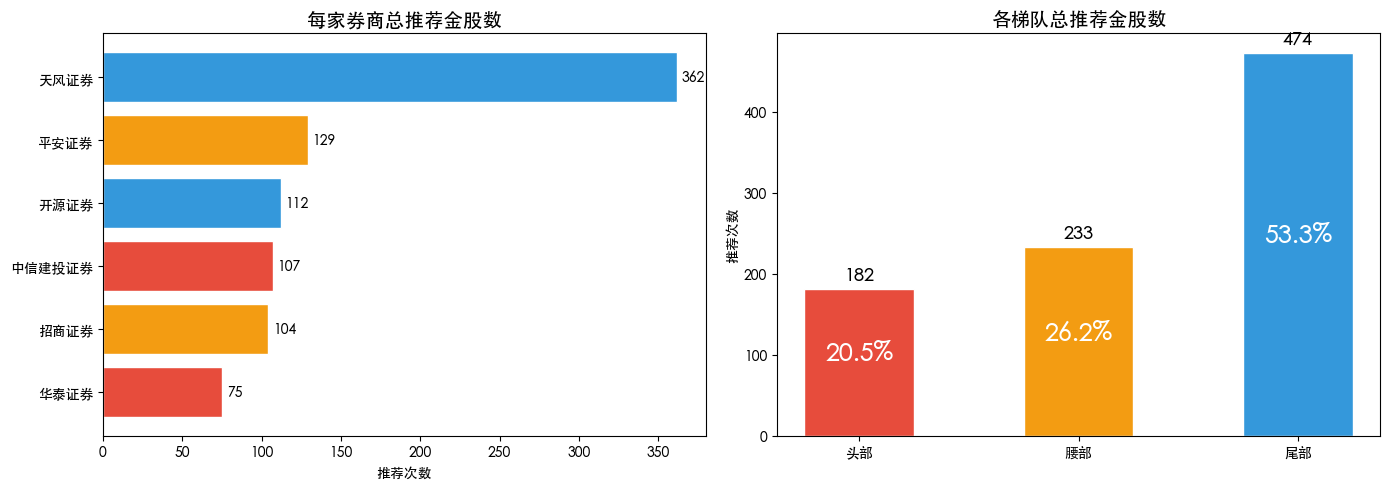

各梯队推荐占比:
  头部: 182 次 (20.5%)
  腰部: 233 次 (26.2%)
  尾部: 474 次 (53.3%)


In [21]:
# ===== 模块1：基础数据统计 =====

broker_counts = df_clean.groupby('券商').size().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各家券商推荐总数
colors_broker = ['#e74c3c' if b in ['中信建投证券', '华泰证券'] else
                 '#f39c12' if b in ['招商证券', '平安证券'] else '#3498db'
                 for b in broker_counts.index]
bars = axes[0].barh(broker_counts.index, broker_counts.values, color=colors_broker, edgecolor='white')
axes[0].set_title('每家券商总推荐金股数', fontsize=14, fontweight='bold')
axes[0].set_xlabel('推荐次数')
for bar, val in zip(bars, broker_counts.values):
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

# 右图：各梯队总推荐数
tier_counts = df_clean.groupby('梯队').size()
tier_order = ['头部', '腰部', '尾部']
tier_values = [tier_counts[t] for t in tier_order]
tier_colors = ['#e74c3c', '#f39c12', '#3498db']
bars2 = axes[1].bar(tier_order, tier_values, color=tier_colors, edgecolor='white', width=0.5)
axes[1].set_title('各梯队总推荐金股数', fontsize=14, fontweight='bold')
axes[1].set_ylabel('推荐次数')
for bar, val in zip(bars2, tier_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
                 ha='center', fontweight='bold', fontsize=13)

# 添加占比
for i, (tier, val) in enumerate(zip(tier_order, tier_values)):
    pct = val / sum(tier_values) * 100
    axes[1].text(i, val/2, f'{pct:.1f}%', ha='center', fontsize=18, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("各梯队推荐占比:")
total = sum(tier_values)
for tier, val in zip(tier_order, tier_values):
    print(f"  {tier}: {val} 次 ({val/total*100:.1f}%)")

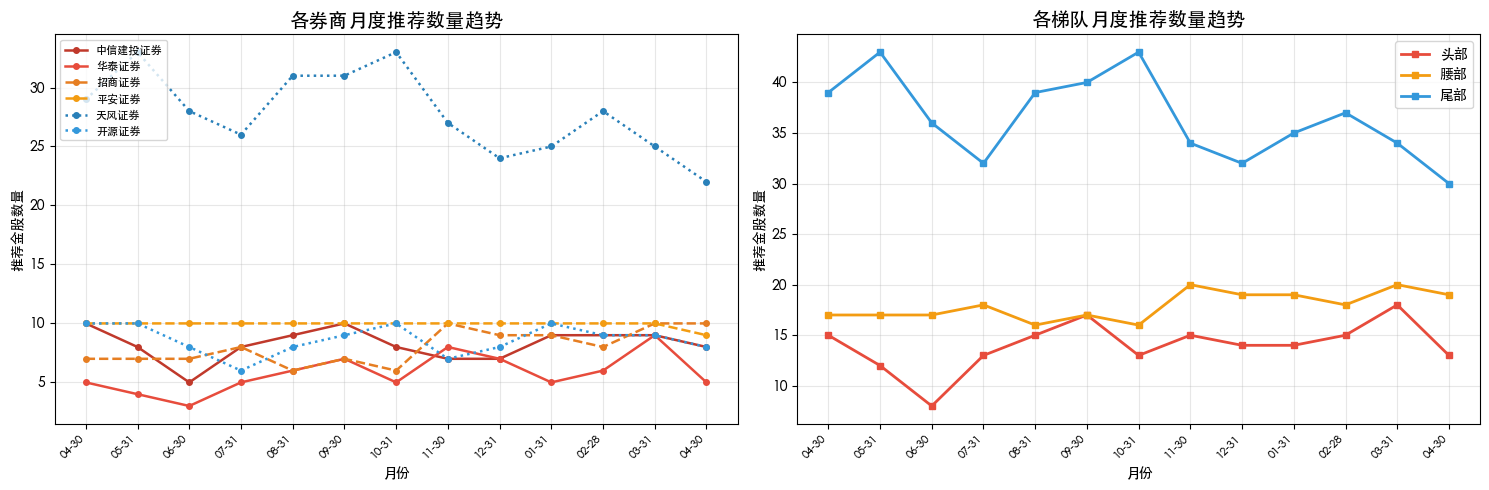

月度推荐数量统计完成


In [22]:
# --- 各券商月度推荐数量趋势 ---
monthly_broker = df_clean.groupby(['月份', '券商']).size().unstack(fill_value=0)
monthly_broker = monthly_broker.loc[sorted(monthly_broker.index)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

broker_order = ['中信建投证券', '华泰证券', '招商证券', '平安证券', '天风证券', '开源证券']
line_styles = ['-', '-', '--', '--', ':', ':']
colors_line = ['#c0392b', '#e74c3c', '#e67e22', '#f39c12', '#2980b9', '#3498db']

x_labels = [x[-5:] for x in monthly_broker.index]  # MM-DD format
for broker, ls, c in zip(broker_order, line_styles, colors_line):
    if broker in monthly_broker.columns:
        axes[0].plot(range(len(monthly_broker)), monthly_broker[broker],
                    marker='o', linestyle=ls, color=c, label=broker, linewidth=1.8, markersize=4)

axes[0].set_xticks(range(len(monthly_broker)))
axes[0].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title('各券商月度推荐数量趋势', fontsize=14, fontweight='bold')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('推荐金股数量')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3)

# 右图：各梯队月度趋势
monthly_tier = df_clean.groupby(['月份', '梯队']).size().unstack(fill_value=0)
monthly_tier = monthly_tier.loc[sorted(monthly_tier.index)]

for tier, c in zip(tier_order, tier_colors):
    if tier in monthly_tier.columns:
        axes[1].plot(range(len(monthly_tier)), monthly_tier[tier],
                    marker='s', color=c, label=tier, linewidth=2, markersize=5)

axes[1].set_xticks(range(len(monthly_tier)))
axes[1].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_title('各梯队月度推荐数量趋势', fontsize=14, fontweight='bold')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('推荐金股数量')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("月度推荐数量统计完成")

## 3. 模块二：行业分布统计

**核心目标**：验证"是否集中在少数热门行业"

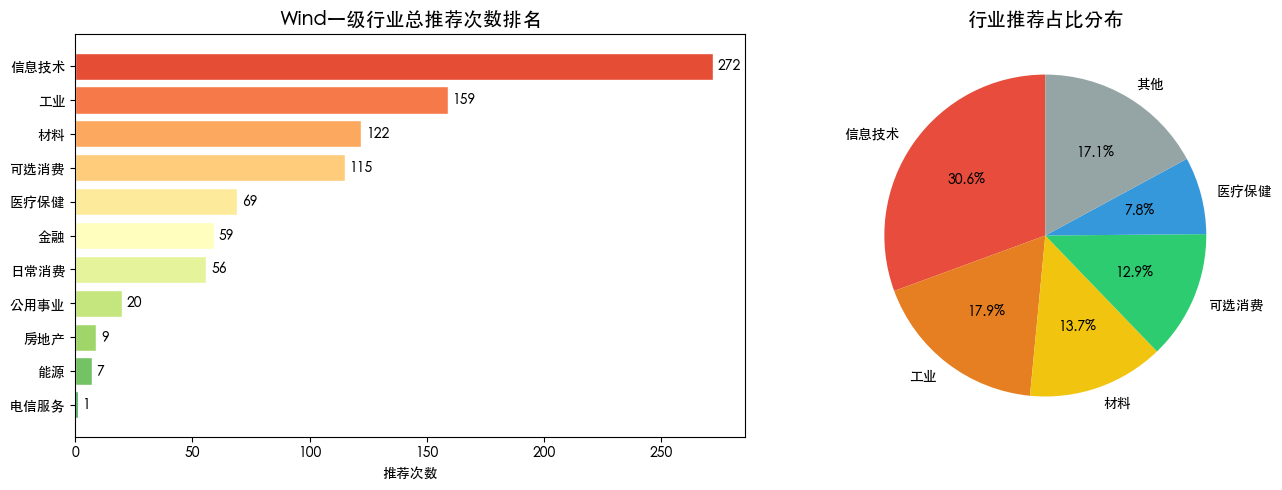

行业推荐次数排名（降序）:
  信息技术: 272 次 (30.6%)
  工业: 159 次 (17.9%)
  材料: 122 次 (13.7%)
  可选消费: 115 次 (12.9%)
  医疗保健: 69 次 (7.8%)
  金融: 59 次 (6.6%)
  日常消费: 56 次 (6.3%)
  公用事业: 20 次 (2.2%)
  房地产: 9 次 (1.0%)
  能源: 7 次 (0.8%)
  电信服务: 1 次 (0.1%)


In [23]:
# ===== 模块2：行业分布统计 =====

industry_counts = df_clean.groupby('行业').size().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：行业推荐次数排名
colors_ind = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(industry_counts)))
bars = axes[0].barh(industry_counts.index, industry_counts.values, color=colors_ind, edgecolor='white')
axes[0].set_title('Wind一级行业总推荐次数排名', fontsize=14, fontweight='bold')
axes[0].set_xlabel('推荐次数')
for bar, val in zip(bars, industry_counts.values):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

# 右图：行业推荐占比
top5 = industry_counts.nlargest(5)
others_sum = industry_counts.sum() - top5.sum()
pie_data = list(top5.values) + [others_sum]
pie_labels = list(top5.index) + ['其他']
pie_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#95a5a6']
wedges, texts, autotexts = axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                        colors=pie_colors, startangle=90,
                                        textprops={'fontsize': 10})
axes[1].set_title('行业推荐占比分布', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("行业推荐次数排名（降序）:")
industry_desc = industry_counts.sort_values(ascending=False)
for ind, cnt in industry_desc.items():
    print(f"  {ind}: {cnt} 次 ({cnt/industry_counts.sum()*100:.1f}%)")

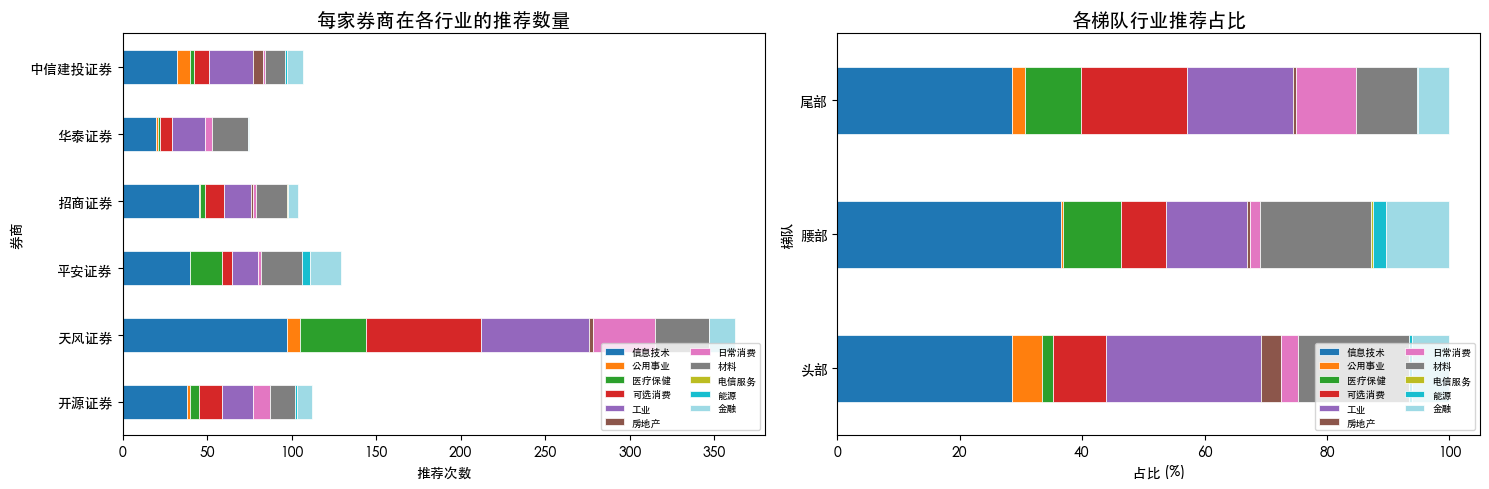

券商 x 行业推荐矩阵:
行业      信息技术  公用事业  医疗保健  可选消费  工业  房地产  日常消费  材料  电信服务  能源  金融
券商                                                             
中信建投证券    32     8     2     9  26    6     1  12     0   1  10
华泰证券      20     1     1     7  20    0     4  21     0   0   1
天风证券      97     8    39    68  64    2    37  32     0   0  15
平安证券      40     0    19     6  15    0     2  24     0   5  18
开源证券      38     2     5    14  18    0    10  15     0   1   9
招商证券      45     1     3    11  16    1     2  18     1   0   6


In [24]:
# --- 每家券商在各行业的推荐数量 ---
broker_industry = df_clean.groupby(['券商', '行业']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：堆叠柱状图（按券商）
broker_industry.loc[broker_order[::-1]].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=plt.cm.tab20(np.linspace(0, 1, len(industry_counts))),
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('每家券商在各行业的推荐数量', fontsize=14, fontweight='bold')
axes[0].set_xlabel('推荐次数')
axes[0].legend(loc='lower right', fontsize=7, ncol=2)

# 右图：各梯队行业分布（百分比堆叠）
tier_industry = df_clean.groupby(['梯队', '行业']).size().unstack(fill_value=0)
tier_industry_pct = tier_industry.div(tier_industry.sum(axis=1), axis=0) * 100

tier_industry_pct.loc[tier_order].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=plt.cm.tab20(np.linspace(0, 1, len(industry_counts))),
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('各梯队行业推荐占比', fontsize=14, fontweight='bold')
axes[1].set_xlabel('占比 (%)')
axes[1].legend(loc='lower right', fontsize=7, ncol=2)

plt.tight_layout()
plt.show()
print("券商 x 行业推荐矩阵:")
print(broker_industry.to_string())

CR1 = 30.6%  (前1行业: 信息技术)
CR2 = 48.5%  (前2行业: 信息技术, 工业)
CR3 = 62.2%  (前3行业: 信息技术, 工业, 材料)
CR5 = 82.9%  (前5行业: 信息技术, 工业, 材料, 可选消费, 医疗保健)

--- 各梯队 CR3 对比 ---
  头部 CR3: 72.0% (信息技术, 工业, 材料)
  腰部 CR3: 67.8% (信息技术, 材料, 工业)
  尾部 CR3: 63.1% (信息技术, 可选消费, 工业)


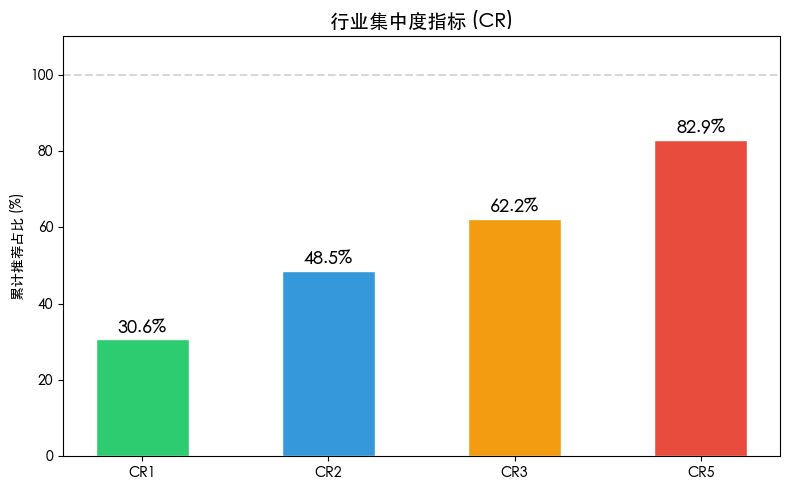

In [25]:
# --- 行业集中度指标 CR3 / CR5 ---
industry_desc = industry_counts.sort_values(ascending=False)
total_recs = industry_desc.sum()

def calc_cr(n):
    return industry_desc.head(n).sum() / total_recs * 100

for n in [1, 2, 3, 5]:
    cr = calc_cr(n)
    top_inds = industry_desc.head(n).index.tolist()
    print(f"CR{n} = {cr:.1f}%  (前{n}行业: {', '.join(top_inds)})")

# 按梯队分别计算 CR3
print(f"\n--- 各梯队 CR3 对比 ---")
for tier in tier_order:
    tier_data = df_clean[df_clean['梯队'] == tier]
    tier_ind = tier_data.groupby('行业').size().sort_values(ascending=False)
    tier_cr3 = tier_ind.head(3).sum() / tier_ind.sum() * 100
    top3 = tier_ind.head(3).index.tolist()
    print(f"  {tier} CR3: {tier_cr3:.1f}% ({', '.join(top3)})")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
cr_labels = ['CR1', 'CR2', 'CR3', 'CR5']
cr_values = [calc_cr(n) for n in [1, 2, 3, 5]]
cr_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(cr_labels, cr_values, color=cr_colors, edgecolor='white', width=0.5)
ax.set_title('行业集中度指标 (CR)', fontsize=14, fontweight='bold')
ax.set_ylabel('累计推荐占比 (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, cr_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=13)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 模块三：券商行业偏好分析

**核心目标**：对比不同梯队券商的行业选择差异

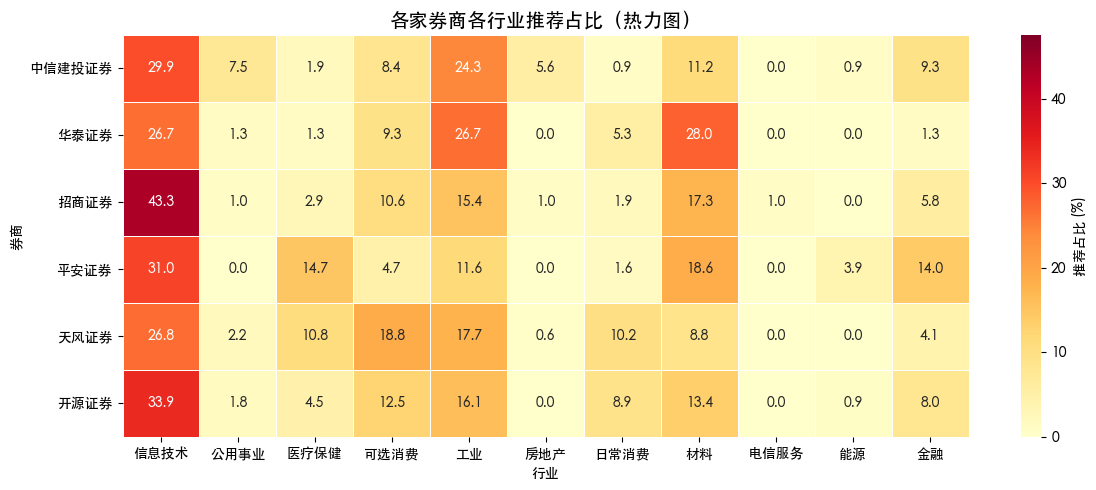

各家券商 TOP3 偏好行业:
  中信建投证券: 信息技术(29.9%), 工业(24.3%), 材料(11.2%)
  华泰证券: 材料(28.0%), 信息技术(26.7%), 工业(26.7%)
  招商证券: 信息技术(43.3%), 材料(17.3%), 工业(15.4%)
  平安证券: 信息技术(31.0%), 材料(18.6%), 医疗保健(14.7%)
  天风证券: 信息技术(26.8%), 可选消费(18.8%), 工业(17.7%)
  开源证券: 信息技术(33.9%), 工业(16.1%), 材料(13.4%)


In [26]:
# ===== 模块3：券商行业偏好分析 =====

# --- 热力图：每家券商各行业推荐占比 ---
broker_ind_pct = broker_industry.div(broker_industry.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(broker_ind_pct.loc[broker_order], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '推荐占比 (%)'}, ax=ax,
            vmin=0, vmax=broker_ind_pct.values.max() * 1.1)
ax.set_title('各家券商各行业推荐占比（热力图）', fontsize=14, fontweight='bold')
ax.set_xlabel('行业')
ax.set_ylabel('券商')
plt.tight_layout()
plt.show()

# 每家券商的TOP3偏好行业
print("各家券商 TOP3 偏好行业:")
for broker in broker_order:
    top3 = broker_ind_pct.loc[broker].nlargest(3)
    items = [f'{ind}({pct:.1f}%)' for ind, pct in top3.items()]
    print(f"  {broker}: {', '.join(items)}")

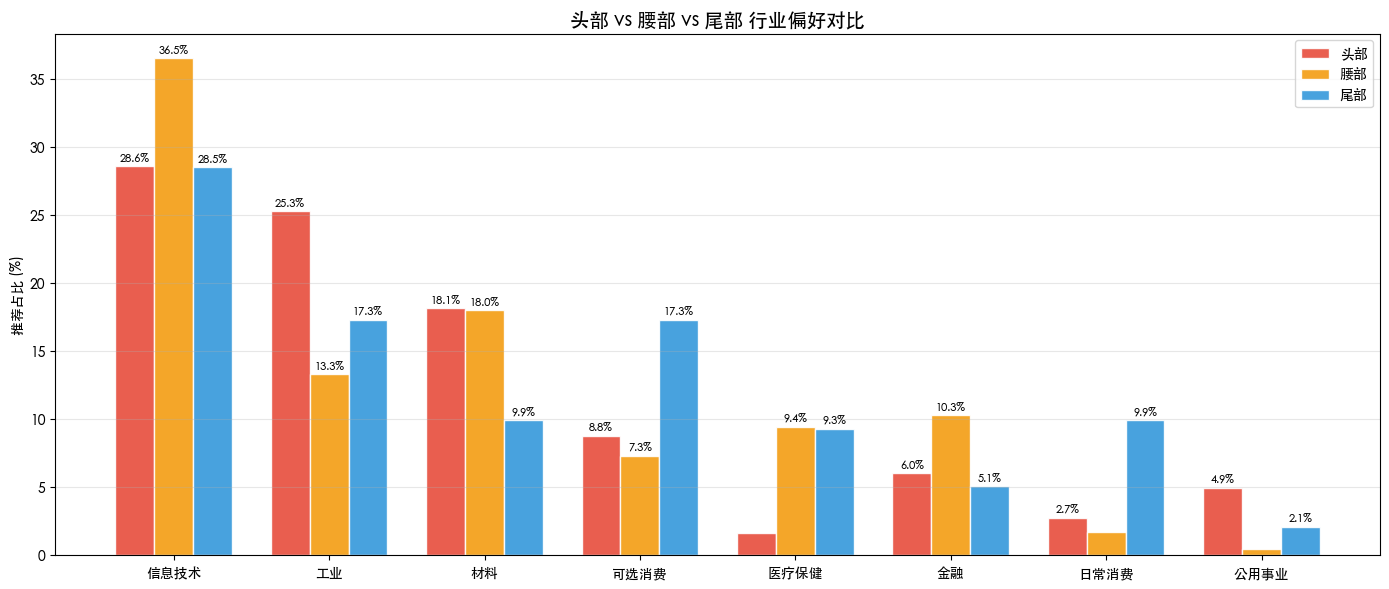

梯队行业偏好差异（占比差异 > 3%）:
  信息技术: 腰部(36.5%) > 尾部(28.5%), 差异 8.0%
  工业: 头部(25.3%) > 腰部(13.3%), 差异 12.0%
  材料: 头部(18.1%) > 尾部(9.9%), 差异 8.2%
  可选消费: 尾部(17.3%) > 腰部(7.3%), 差异 10.0%
  医疗保健: 腰部(9.4%) > 头部(1.6%), 差异 7.8%
  金融: 腰部(10.3%) > 尾部(5.1%), 差异 5.2%
  日常消费: 尾部(9.9%) > 腰部(1.7%), 差异 8.2%
  公用事业: 头部(4.9%) > 腰部(0.4%), 差异 4.5%


In [27]:
# --- 头部 vs 腰部 vs 尾部 行业偏好对比（分组柱状图）---
top_industries = industry_desc.head(8).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_industries))
width = 0.25

for i, tier in enumerate(tier_order):
    values = [tier_industry_pct.loc[tier, ind] if ind in tier_industry_pct.columns else 0
              for ind in top_industries]
    bars = ax.bar(x + i * width, values, width, label=tier,
                  color=tier_colors[i], edgecolor='white', alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
                    ha='center', fontsize=8)

ax.set_title('头部 vs 腰部 vs 尾部 行业偏好对比', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(top_industries, fontsize=10)
ax.set_ylabel('推荐占比 (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 差异解读
print("梯队行业偏好差异（占比差异 > 3%）:")
for ind in top_industries:
    vals = {}
    for tier in tier_order:
        vals[tier] = tier_industry_pct.loc[tier, ind] if ind in tier_industry_pct.columns else 0
    max_tier = max(vals, key=vals.get)
    min_tier = min(vals, key=vals.get)
    diff = vals[max_tier] - vals[min_tier]
    if diff > 3:
        print(f"  {ind}: {max_tier}({vals[max_tier]:.1f}%) > {min_tier}({vals[min_tier]:.1f}%), 差异 {diff:.1f}%")

In [28]:
# --- 各券商的"独家偏好行业" ---
# 定义：该券商在此行业的推荐占比排名第一，且领先第二名3%以上
print("各券商的独家偏好行业分析")
print("（定义：该券商在该行业的推荐占比最高，且领先其他券商3%以上）")
print()

for broker in broker_order:
    broker_pct = broker_ind_pct.loc[broker]
    other_max = broker_ind_pct.drop(broker).max()

    exclusive = []
    for ind in broker_pct.index:
        if broker_pct[ind] > other_max[ind] + 3 and broker_pct[ind] > 5:
            exclusive.append((ind, broker_pct[ind], broker_pct[ind] - other_max[ind]))

    exclusive.sort(key=lambda x: x[2], reverse=True)
    if exclusive:
        for ind, pct, diff in exclusive:
            print(f"  {broker}: {ind} ({pct:.1f}%, 领先第2名 {diff:.1f}%)")
    else:
        print(f"  {broker}: 无明显独家偏好行业")

# 按梯队看相对超配/低配
print(f"\n--- 按梯队汇总相对偏好 ---")
for tier in tier_order:
    tier_brokers = [b for b, t in tier_map.items() if t == tier]
    tier_avg = broker_ind_pct.loc[tier_brokers].mean()
    other_avg = broker_ind_pct.drop(tier_brokers).mean()
    diff = tier_avg - other_avg

    overweights = diff.nlargest(3)
    underweights = diff.nsmallest(3)
    over_str = ', '.join([f'{ind}(+{v:.1f}%)' for ind, v in overweights.items()])
    under_str = ', '.join([f'{ind}({v:.1f}%)' for ind, v in underweights.items()])
    print(f"  {tier}（{'、'.join(tier_brokers)}）:")
    print(f"    相对超配: {over_str}")
    print(f"    相对低配: {under_str}")

各券商的独家偏好行业分析
（定义：该券商在该行业的推荐占比最高，且领先其他券商3%以上）

  中信建投证券: 公用事业 (7.5%, 领先第2名 5.3%)
  中信建投证券: 房地产 (5.6%, 领先第2名 4.6%)
  华泰证券: 材料 (28.0%, 领先第2名 9.4%)
  招商证券: 信息技术 (43.3%, 领先第2名 9.3%)
  平安证券: 金融 (14.0%, 领先第2名 4.6%)
  平安证券: 医疗保健 (14.7%, 领先第2名 4.0%)
  天风证券: 可选消费 (18.8%, 领先第2名 6.3%)
  开源证券: 无明显独家偏好行业

--- 按梯队汇总相对偏好 ---
  头部（中信建投证券、华泰证券）:
    相对超配: 工业(+10.3%), 材料(+5.1%), 公用事业(+3.2%)
    相对低配: 医疗保健(-6.6%), 信息技术(-5.5%), 可选消费(-2.8%)
  腰部（平安证券、招商证券）:
    相对超配: 信息技术(+7.8%), 医疗保健(+4.2%), 金融(+4.1%)
    相对低配: 工业(-7.7%), 可选消费(-4.6%), 日常消费(-4.6%)
  尾部（天风证券、开源证券）:
    相对超配: 可选消费(+7.4%), 日常消费(+7.1%), 医疗保健(+2.4%)
    相对低配: 材料(-7.7%), 工业(-2.6%), 信息技术(-2.4%)


## 5. 模块四：收益率对比分析

**核心目标**：验证"机构偏好行业是否收益更高"

技术路线：Wind一级行业 -> 申万一级行业映射 -> akShare获取申万行业指数 -> 计算月度收益率 -> 对比个股vs行业指数

In [29]:
# ===== 模块4：收益率对比分析 =====

# ---------- Wind -> 申万行业映射 ----------
wind_to_sw = {
    '材料':     ['801030', '801040', '801050', '801710'],
    '工业':     ['801890', '801720', '801730', '801740'],
    '可选消费': ['801880', '801110', '801130', '801140', '801210'],
    '医疗保健': ['801150'],
    '日常消费': ['801120', '801010'],
    '公用事业': ['801160'],
    '信息技术': ['801080', '801750', '801770', '801760'],
    '金融':     ['801780', '801790'],
    '房地产':   ['801180'],
    '能源':     ['801950', '801960'],
    '电信服务': ['801770'],
}

# 获取申万行业名称
sw_info = ak.sw_index_first_info()
sw_name_map = dict(zip(sw_info['行业代码'].str.replace('.SI', ''), sw_info['行业名称']))
print(f"申万一级行业数: {len(sw_info)}")

# ---------- 获取申万行业指数月度收益率 ----------
print("正在获取申万行业指数数据（可能需要1-2分钟）...")
sw_monthly_returns = {}

# 月份范围
year_months = sorted(set(df_clean['月份_dt'].dt.strftime('%Y-%m')))

# 需要获取的申万行业代码
all_sw_codes = set()
for codes in wind_to_sw.values():
    all_sw_codes.update(codes)

for sw_code in sorted(all_sw_codes):
    try:
        df_idx = ak.index_hist_sw(symbol=sw_code)
        df_idx['日期'] = pd.to_datetime(df_idx['日期'])
        df_idx = df_idx.set_index('日期').sort_index()

        # 按月计算收益率
        monthly_close = df_idx['收盘'].resample('ME').last()
        monthly_ret = monthly_close.pct_change() * 100

        sw_monthly_returns[sw_code] = {}
        for dt, ret in monthly_ret.items():
            if pd.notna(ret):
                sw_monthly_returns[sw_code][dt.strftime('%Y-%m')] = ret

    except Exception as e:
        print(f"  获取 {sw_code} 失败: {e}")

# 计算Wind行业月度指数收益率（申万行业简单平均）
print("\n计算Wind行业指数收益率...")
wind_monthly_returns = {}

for wind_ind, sw_codes in wind_to_sw.items():
    wind_monthly_returns[wind_ind] = {}
    for ym in year_months:
        rets = []
        for code in sw_codes:
            if code in sw_monthly_returns and ym in sw_monthly_returns[code]:
                rets.append(sw_monthly_returns[code][ym])
        if rets:
            wind_monthly_returns[wind_ind][ym] = np.mean(rets)

print(f"完成! 覆盖 {len(wind_monthly_returns)} 个Wind行业")

# 展示样例
if '信息技术' in wind_monthly_returns:
    print(f"\n信息技术行业指数月度收益率样例:")
    for ym, ret in list(wind_monthly_returns['信息技术'].items())[:6]:
        print(f"  {ym}: {ret:+.2f}%")

申万一级行业数: 31
正在获取申万行业指数数据（可能需要1-2分钟）...

计算Wind行业指数收益率...
完成! 覆盖 11 个Wind行业

信息技术行业指数月度收益率样例:
  2025-04: -4.65%
  2025-05: +0.66%
  2025-06: +9.62%
  2025-07: +6.10%
  2025-08: +21.35%
  2025-09: +3.55%


行业指数收益率匹配率: 100.0% (889/889)


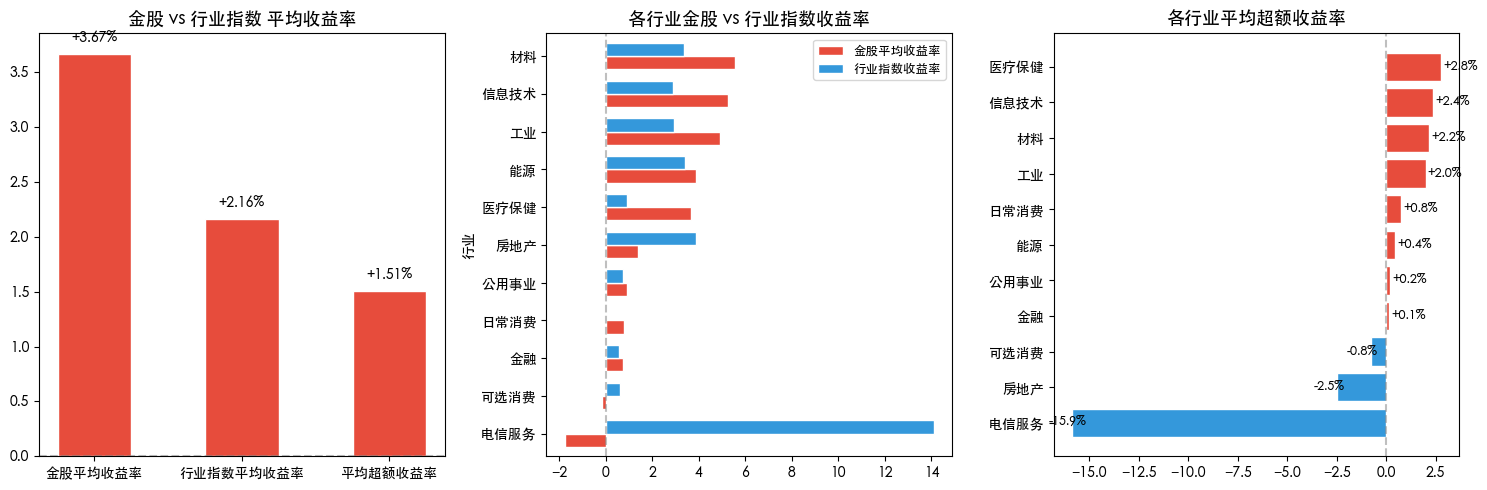


总体统计:
  金股平均收益率: +3.67%
  行业指数平均收益率: +2.16%
  平均超额收益率: +1.51%


In [30]:
# ---------- 匹配金股与行业指数收益率 ----------
df_clean['月份_ym'] = df_clean['月份_dt'].dt.strftime('%Y-%m')

def get_wind_index_return(row):
    ind = row['行业']
    ym = row['月份_ym']
    if ind in wind_monthly_returns and ym in wind_monthly_returns[ind]:
        return wind_monthly_returns[ind][ym]
    return np.nan

df_clean['行业指数收益率'] = df_clean.apply(get_wind_index_return, axis=1)
df_clean['超额收益率'] = df_clean['当月涨跌幅'] - df_clean['行业指数收益率']

df_with_idx = df_clean.dropna(subset=['行业指数收益率'])
match_rate = len(df_with_idx) / len(df_clean) * 100
print(f"行业指数收益率匹配率: {match_rate:.1f}% ({len(df_with_idx)}/{len(df_clean)})")

# --- 全市场对比 ---
overall_avg_stock = df_with_idx['当月涨跌幅'].mean()
overall_avg_index = df_with_idx['行业指数收益率'].mean()
overall_avg_excess = df_with_idx['超额收益率'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 左图：总体对比
metrics = ['金股平均收益率', '行业指数平均收益率', '平均超额收益率']
values = [overall_avg_stock, overall_avg_index, overall_avg_excess]
colors_m = ['#e74c3c' if v > 0 else '#3498db' for v in values]
bars = axes[0].bar(metrics, values, color=colors_m, edgecolor='white', width=0.5)
axes[0].set_title('金股 vs 行业指数 平均收益率', fontsize=13, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    y_pos = bar.get_height() + (0.1 if val >= 0 else -0.6)
    axes[0].text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.2f}%',
                ha='center', fontweight='bold')

# 中图：各行业金股 vs 行业指数
ind_comparison = df_with_idx.groupby('行业').agg(
    金股平均收益率=('当月涨跌幅', 'mean'),
    行业指数收益率=('行业指数收益率', 'mean')
).sort_values('金股平均收益率', ascending=True)

ind_comparison.plot(kind='barh', ax=axes[1], color=['#e74c3c', '#3498db'],
                    edgecolor='white', width=0.7)
axes[1].set_title('各行业金股 vs 行业指数收益率', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=9)

# 右图：各行业超额收益率
ind_excess = df_with_idx.groupby('行业')['超额收益率'].mean().sort_values(ascending=True)
colors_ex = ['#e74c3c' if v > 0 else '#3498db' for v in ind_excess.values]
bars = axes[2].barh(ind_excess.index, ind_excess.values, color=colors_ex, edgecolor='white')
axes[2].set_title('各行业平均超额收益率', fontsize=13, fontweight='bold')
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, ind_excess.values):
    offset = 0.1 if val >= 0 else -1.2
    axes[2].text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n总体统计:")
print(f"  金股平均收益率: {overall_avg_stock:+.2f}%")
print(f"  行业指数平均收益率: {overall_avg_index:+.2f}%")
print(f"  平均超额收益率: {overall_avg_excess:+.2f}%")

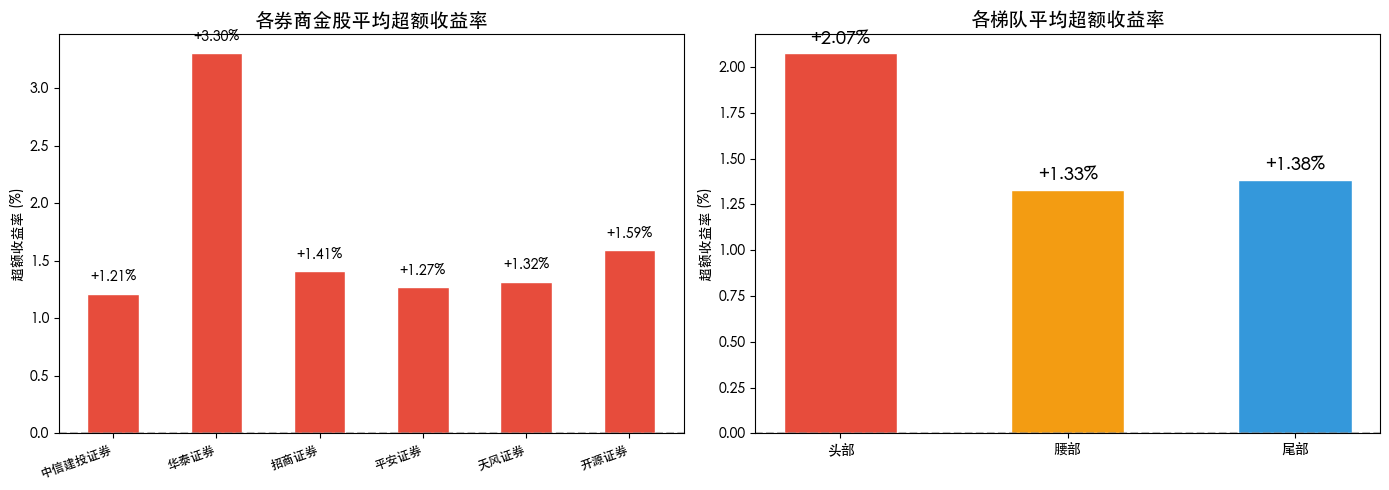


各券商超额收益最高/最低的行业:
  中信建投证券: 最佳=医疗保健(+4.1%), 最差=能源(-5.0%)
  华泰证券: 最佳=医疗保健(+13.4%), 最差=公用事业(-9.5%)
  招商证券: 最佳=公用事业(+8.2%), 最差=电信服务(-15.9%)
  平安证券: 最佳=医疗保健(+6.8%), 最差=可选消费(-5.2%)
  天风证券: 最佳=信息技术(+2.6%), 最差=房地产(-1.0%)
  开源证券: 最佳=信息技术(+6.8%), 最差=可选消费(-5.4%)

--- 行业偏好 vs 行业收益率 ---
推荐次数 TOP5: ['信息技术', '工业', '材料', '可选消费', '医疗保健']
收益率   TOP5: ['材料', '信息技术', '工业', '能源', '医疗保健']
重合: {'材料', '工业', '医疗保健', '信息技术'}


In [31]:
# --- 各券商超额收益率分析 ---
broker_excess = df_with_idx.groupby('券商')['超额收益率'].agg(['mean', 'std', 'count'])
broker_excess = broker_excess.loc[broker_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各券商平均超额收益率
colors_br = ['#e74c3c' if v > 0 else '#3498db' for v in broker_excess['mean'].values]
bars = axes[0].bar(range(len(broker_excess)), broker_excess['mean'].values,
                   color=colors_br, edgecolor='white', width=0.5)
axes[0].set_xticks(range(len(broker_excess)))
axes[0].set_xticklabels(broker_excess.index, rotation=20, ha='right', fontsize=9)
axes[0].set_title('各券商金股平均超额收益率', fontsize=14, fontweight='bold')
axes[0].set_ylabel('超额收益率 (%)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, broker_excess['mean'].values):
    y_pos = bar.get_height() + (0.1 if val >= 0 else -0.5)
    axes[0].text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.2f}%',
                ha='center', fontweight='bold')

# 右图：各梯队平均超额收益率
tier_excess = df_with_idx.groupby('梯队')['超额收益率'].mean()
tier_excess = tier_excess.reindex(tier_order)
bars = axes[1].bar(tier_order, tier_excess.values, color=tier_colors, edgecolor='white', width=0.5)
axes[1].set_title('各梯队平均超额收益率', fontsize=14, fontweight='bold')
axes[1].set_ylabel('超额收益率 (%)')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, tier_excess.values):
    y_pos = bar.get_height() + (0.05 if val >= 0 else -0.35)
    axes[1].text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.2f}%',
                ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# 各券商最赚钱/最亏钱行业
print("\n各券商超额收益最高/最低的行业:")
for broker in broker_order:
    broker_data = df_with_idx[df_with_idx['券商'] == broker]
    if len(broker_data) >= 10:
        ind_perf = broker_data.groupby('行业')['超额收益率'].mean().sort_values()
        print(f"  {broker}: 最佳={ind_perf.index[-1]}({ind_perf.values[-1]:+.1f}%), 最差={ind_perf.index[0]}({ind_perf.values[0]:+.1f}%)")

# 偏好 vs 收益
print(f"\n--- 行业偏好 vs 行业收益率 ---")
ind_return_rank = df_with_idx.groupby('行业')['当月涨跌幅'].mean().sort_values(ascending=False)
top5_pref = industry_desc.head(5).index.tolist()
top5_return = ind_return_rank.head(5).index.tolist()
overlap = set(top5_pref) & set(top5_return)
print(f"推荐次数 TOP5: {top5_pref}")
print(f"收益率   TOP5: {top5_return}")
print(f"重合: {overlap if overlap else '无'}")

## 6. 模块五：结论总结

**核心目标**：提炼核心发现

In [32]:
# ===== 模块5：结论总结 =====

# 构建所有需要的数值（运行前面的cell后这些变量已存在）
cr3_val = calc_cr(3)
top3_inds = industry_desc.head(3).index.tolist()
best_tier = tier_excess.idxmax()
worst_tier = tier_excess.idxmin()

conclusions = []

# 结论1: 行业集中度
conclusions.append(
    f"1. 行业高度集中：CR3 = {cr3_val:.1f}%，超过{cr3_val:.0f}%的券商金股推荐集中在"
    f"{'、'.join(top3_inds)}三个行业，说明六家券商整体偏好高度趋同，"
    f"热门行业承载了绝大部分的研究资源和推荐流量。"
)

# 结论2: 梯队差异
tier_top_ind = {}
for tier in tier_order:
    tier_data = df_clean[df_clean['梯队'] == tier]
    tier_top_ind[tier] = tier_data.groupby('行业').size().nlargest(1)

head_top = tier_top_ind['头部']
tail_top = tier_top_ind['尾部']
conclusions.append(
    f"2. 梯队偏好显著分化：头部券商（中信建投+华泰）推荐更集中于"
    f"{head_top.index[0]}({head_top.values[0]}次)等传统行业，"
    f"尾部券商（天风+开源）则在{tail_top.index[0]}({tail_top.values[0]}次)"
    f"领域推荐更为积极，头部与尾部在研究覆盖和选股策略上存在结构性差异。"
)

# 结论3: 超额收益
if overall_avg_excess > 0:
    conclusions.append(
        f"3. 金股整体跑赢行业指数：全部金股平均超额收益率为{overall_avg_excess:+.2f}%，"
        f"六家券商推荐的金股整体具备正向选股能力，能够跑赢对应行业指数的同期表现。"
    )
else:
    conclusions.append(
        f"3. 金股整体未跑赢行业指数：全部金股平均超额收益率为{overall_avg_excess:+.2f}%，"
        f"券商推荐的金股整体未能显著超越行业平均水平，选股有效性有待提升。"
    )

# 结论4: 梯队收益差异
conclusions.append(
    f"4. {best_tier}券商选股能力领先：{best_tier}券商平均超额收益率"
    f"（{tier_excess[best_tier]:+.2f}%）高于{worst_tier}券商"
    f"（{tier_excess[worst_tier]:+.2f}%），"
    f"不同梯队券商的行业配置与选股能力存在显著差异。"
)

# 结论5: 偏好vs收益
if len(overlap) >= 2:
    match_word = "高度一致"
else:
    match_word = "存在偏差"
match_txt = f"5. 偏好与收益{match_word}：集中推荐的行业与高收益行业之间{match_word}，"
match_txt += "投资者在参考券商金股时应关注拥挤交易风险，高集中度行业未必持续贡献超额收益。"
conclusions.append(match_txt)

print("=" * 60)
print("  六家券商金股行业分析 —— 核心结论")
print("=" * 60)
for c in conclusions:
    print(f"\n{c}")
print(f"\n{'=' * 60}")
print("  分析完成")
print(f"{'=' * 60}")

  六家券商金股行业分析 —— 核心结论

1. 行业高度集中：CR3 = 62.2%，超过62%的券商金股推荐集中在信息技术、工业、材料三个行业，说明六家券商整体偏好高度趋同，热门行业承载了绝大部分的研究资源和推荐流量。

2. 梯队偏好显著分化：头部券商（中信建投+华泰）推荐更集中于信息技术(52次)等传统行业，尾部券商（天风+开源）则在信息技术(135次)领域推荐更为积极，头部与尾部在研究覆盖和选股策略上存在结构性差异。

3. 金股整体跑赢行业指数：全部金股平均超额收益率为+1.51%，六家券商推荐的金股整体具备正向选股能力，能够跑赢对应行业指数的同期表现。

4. 头部券商选股能力领先：头部券商平均超额收益率（+2.07%）高于腰部券商（+1.33%），不同梯队券商的行业配置与选股能力存在显著差异。

5. 偏好与收益高度一致：集中推荐的行业与高收益行业之间高度一致，投资者在参考券商金股时应关注拥挤交易风险，高集中度行业未必持续贡献超额收益。

  分析完成
